# Introdução a regras de associação

## Slides aula

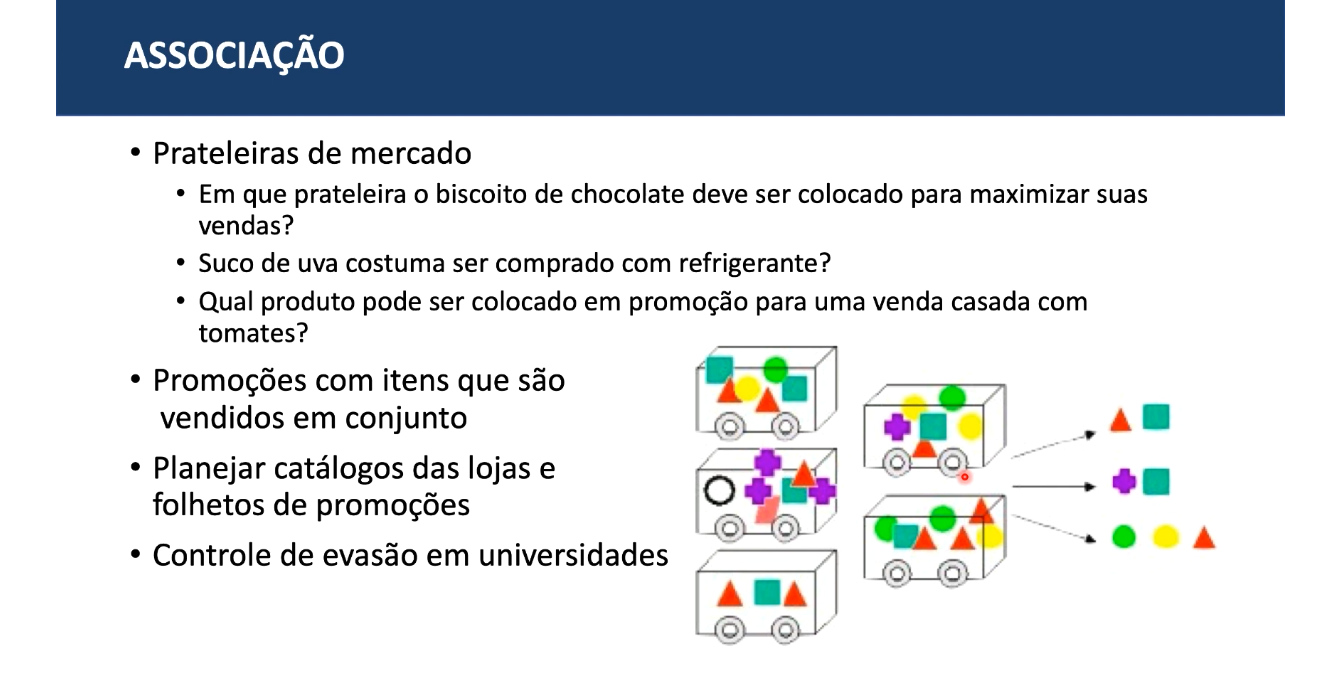

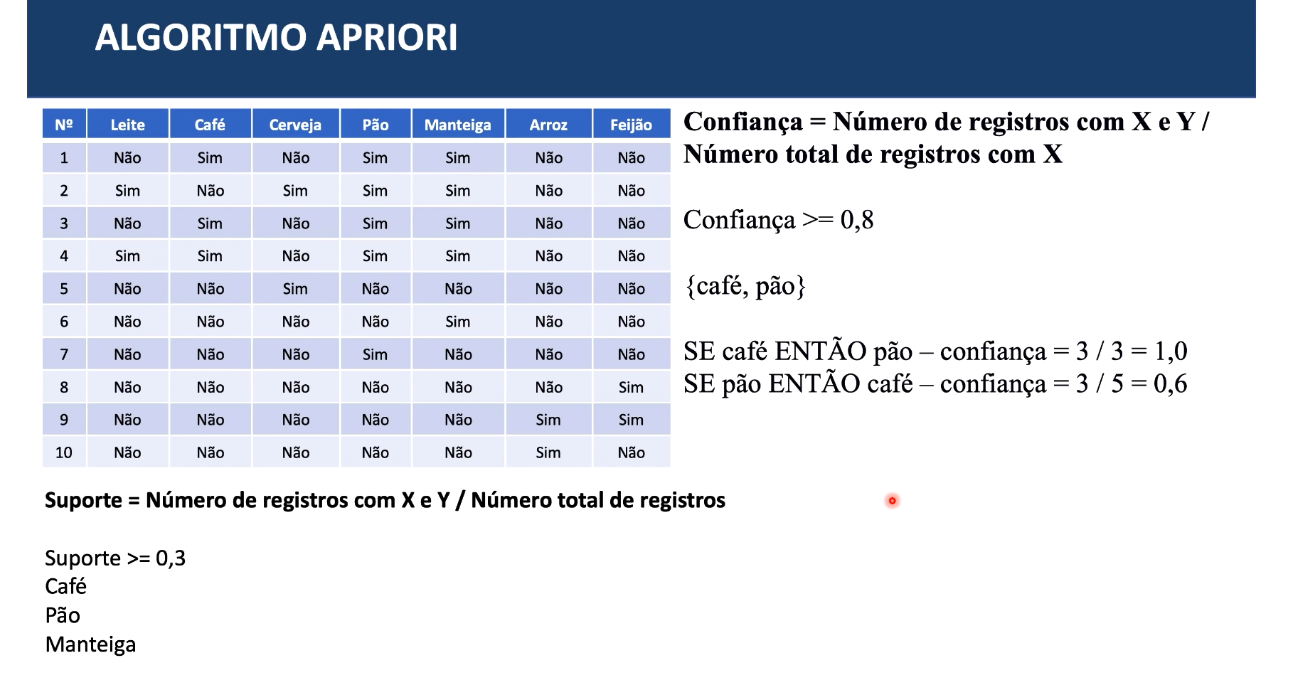

## Implementação

In [1]:
import pandas as pd

dataset = pd.read_csv('Bases de dados/census.csv')
dataset['Age Faixas'] = pd.cut(dataset['age'], bins=[0, 17, 25, 40, 60, 90], labels=['Faixa1', 'Faixa2', 'Faixa3', 'Faixa4', 'Faixa5'])
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             32561 non-null  int64   
 1   workclass       32561 non-null  str     
 2   final-weight    32561 non-null  int64   
 3   education       32561 non-null  str     
 4   education-num   32561 non-null  int64   
 5   marital-status  32561 non-null  str     
 6   occupation      32561 non-null  str     
 7   relationship    32561 non-null  str     
 8   race            32561 non-null  str     
 9   sex             32561 non-null  str     
 10  capital-gain    32561 non-null  int64   
 11  capital-loos    32561 non-null  int64   
 12  hour-per-week   32561 non-null  int64   
 13  native-country  32561 non-null  str     
 14  income          32561 non-null  str     
 15  Age Faixas      32561 non-null  category
dtypes: category(1), int64(6), str(9)
memory usage: 3.8 MB


In [13]:
dataset['Age Faixas'].value_counts()

Age Faixas
Faixa3    12707
Faixa4    11111
Faixa2     6016
Faixa5     2332
Faixa1      395
Name: count, dtype: int64

In [16]:
dataset_apriori = dataset[['Age Faixas', 'workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'native-country', 'income']]
dataset_apriori.shape

(32561, 9)

In [17]:
dataset_apriori = dataset_apriori.sample(n = 1000)
dataset_apriori.shape

(1000, 9)

In [18]:
transacoes = []
for i in range(dataset_apriori.shape[0]):
    transacoes.append([str(dataset_apriori.values[i,j]) for j in range(dataset_apriori.shape[1])])
len(transacoes)

1000

In [19]:
transacoes[:2]

[['Faixa2',
  ' Private',
  ' Some-college',
  ' Never-married',
  ' Sales',
  ' Own-child',
  ' White',
  ' United-States',
  ' <=50K'],
 ['Faixa3',
  ' Private',
  ' Assoc-voc',
  ' Married-civ-spouse',
  ' Adm-clerical',
  ' Husband',
  ' White',
  ' United-States',
  ' >50K']]

In [21]:
from apyori import apriori

In [22]:
regras = apriori(transacoes, min_support = 0.3, min_confidence = 0.2)
resultados = list(regras)

In [24]:
len(resultados)

39

In [25]:
resultados

[RelationRecord(items=frozenset({' <=50K'}), support=0.75, ordered_statistics=[OrderedStatistic(items_base=frozenset(), items_add=frozenset({' <=50K'}), confidence=0.75, lift=1.0)]),
 RelationRecord(items=frozenset({' HS-grad'}), support=0.334, ordered_statistics=[OrderedStatistic(items_base=frozenset(), items_add=frozenset({' HS-grad'}), confidence=0.334, lift=1.0)]),
 RelationRecord(items=frozenset({' Husband'}), support=0.428, ordered_statistics=[OrderedStatistic(items_base=frozenset(), items_add=frozenset({' Husband'}), confidence=0.428, lift=1.0)]),
 RelationRecord(items=frozenset({' Married-civ-spouse'}), support=0.471, ordered_statistics=[OrderedStatistic(items_base=frozenset(), items_add=frozenset({' Married-civ-spouse'}), confidence=0.471, lift=1.0)]),
 RelationRecord(items=frozenset({' Never-married'}), support=0.334, ordered_statistics=[OrderedStatistic(items_base=frozenset(), items_add=frozenset({' Never-married'}), confidence=0.334, lift=1.0)]),
 RelationRecord(items=froze

In [26]:
resultados[12]

RelationRecord(items=frozenset({' United-States', ' <=50K'}), support=0.664, ordered_statistics=[OrderedStatistic(items_base=frozenset(), items_add=frozenset({' United-States', ' <=50K'}), confidence=0.664, lift=1.0), OrderedStatistic(items_base=frozenset({' <=50K'}), items_add=frozenset({' United-States'}), confidence=0.8853333333333334, lift=0.9936401047512159), OrderedStatistic(items_base=frozenset({' United-States'}), items_add=frozenset({' <=50K'}), confidence=0.745230078563412, lift=0.9936401047512159)])